# EDA

In [1]:
import pandas as pd

df = pd.read_csv("Sirikit_upstream_full_multivariate_daily.csv")

print(df.head())


         date  storage_km3  pet_mm_local  t2m_c_local  precip_mm_up  \
0  1987-12-12     4.064504     10.817197    20.619208      0.557841   
1  1987-12-13     4.065823      9.781858    20.670285      0.000000   
2  1987-12-14     4.067143     10.625722    21.699675      0.000000   
3  1987-12-15     4.068463     10.567313    21.073050      0.000000   
4  1987-12-16     4.069783     10.892962    19.960405      0.097901   

   soil_l1_up  soil_l2_up  
0    0.289319    0.336470  
1    0.286609    0.334049  
2    0.284316    0.331854  
3    0.281822    0.329602  
4    0.279642    0.327488  


In [2]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          13169 non-null  object 
 1   storage_km3   13169 non-null  float64
 2   pet_mm_local  13169 non-null  float64
 3   t2m_c_local   13169 non-null  float64
 4   precip_mm_up  13169 non-null  float64
 5   soil_l1_up    13169 non-null  float64
 6   soil_l2_up    13169 non-null  float64
dtypes: float64(6), object(1)
memory usage: 720.3+ KB


date            0
storage_km3     0
pet_mm_local    0
t2m_c_local     0
precip_mm_up    0
soil_l1_up      0
soil_l2_up      0
dtype: int64

In [3]:
df.describe()

,storage_km3,pet_mm_local,t2m_c_local,precip_mm_up,soil_l1_up,soil_l2_up
count,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000
mean,5.000871,9.920675,25.546466,4.008305,0.376538,0.385348
std,1.209229,4.763619,2.510298,7.830745,0.089548,0.079710
min,2.279510,0.634393,12.040124,0.000000,0.249741,0.279262
25%,4.147060,6.261932,24.214523,0.000000,0.276046,0.301590
50%,4.950502,9.299464,25.456694,0.000686,0.395406,0.381012
75%,5.881582,12.906276,26.835901,4.563379,0.466833,0.470671
max,8.417607,25.443878,33.538849,88.647742,0.496127,0.497173


In [4]:
df.isna().sum()

date            0
storage_km3     0
pet_mm_local    0
t2m_c_local     0
precip_mm_up    0
soil_l1_up      0
soil_l2_up      0
dtype: int64

In [5]:
df.columns

Index(['date', 'storage_km3', 'pet_mm_local', 't2m_c_local', 'precip_mm_up',
       'soil_l1_up', 'soil_l2_up'],
      dtype='object')

In [10]:
df[['storage_km3','precip_mm_up','t2m_c_local','pet_mm_local','soil_l1_up','soil_l2_up']].corr()


,storage_km3,precip_mm_up,t2m_c_local,pet_mm_local,soil_l1_up,soil_l2_up
storage_km3,1.000000,-0.234649,-0.167376,0.261650,-0.456126,-0.446309
precip_mm_up,-0.234649,1.000000,0.016639,-0.364235,0.431798,0.411476
t2m_c_local,-0.167376,0.016639,1.000000,0.497677,-0.033789,-0.111826
pet_mm_local,0.261650,-0.364235,0.497677,1.000000,-0.769997,-0.793903
soil_l1_up,-0.456126,0.431798,-0.033789,-0.769997,1.000000,0.951148
soil_l2_up,-0.446309,0.411476,-0.111826,-0.793903,0.951148,1.000000


In [8]:
soil_data = pd.read_csv("soil_data.csv")

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


In [8]:
df_merged = df.copy()


In [9]:
df_merged.head()

,date,storage_km3,pet_mm_local,t2m_c_local,precip_mm_up,soil_l1_up,soil_l2_up
0,1987-12-12,4.064504,10.817197,20.619208,0.557841,0.289319,0.336470
1,1987-12-13,4.065823,9.781858,20.670285,0.000000,0.286609,0.334049
2,1987-12-14,4.067143,10.625722,21.699675,0.000000,0.284316,0.331854
3,1987-12-15,4.068463,10.567313,21.073050,0.000000,0.281822,0.329602
4,1987-12-16,4.069783,10.892962,19.960405,0.097901,0.279642,0.327488


In [29]:
df_merged.columns

Index(['date', 'storage_km3', 'precip_mm', 't2m_c', 'pet_mm', 'soil_l1',
       'soil_l2'],
      dtype='object')

In [13]:
# df_merged already has: date, storage_km3, precip_mm, t2m_c, pet_mm, soil_l1, soil_l2

dfm = df.copy()
dfm["date"] = pd.to_datetime(dfm["date"])
dfm = dfm.sort_values("date")
dfm['soil_l1']=dfm['soil_l1_up']
# drop redundant soil_l2 (0.95 corr with soil_l1)
dfm = dfm.drop(columns=['soil_l1_up',"soil_l2_up",'precip_mm_up','t2m_c_local', 'pet_mm_local'])

# safety: drop any remaining NaNs
dfm = dfm.dropna()

dfm.columns


Index(['date', 'storage_km3', 'soil_l1'], dtype='object')

In [14]:
dfm.head()

,date,storage_km3,soil_l1
0,1987-12-12,4.064504,0.289319
1,1987-12-13,4.065823,0.286609
2,1987-12-14,4.067143,0.284316
3,1987-12-15,4.068463,0.281822
4,1987-12-16,4.069783,0.279642


## Train/Test split by date (no leakage)

In [15]:
cutoff = pd.Timestamp("2016-01-01")

train_df = dfm[dfm["date"] < cutoff].copy()
test_df  = dfm[dfm["date"] >= cutoff].copy()

len(train_df), len(test_df), train_df["date"].min(), train_df["date"].max(), test_df["date"].min()


(10247,
 2922,
 Timestamp('1987-12-12 00:00:00'),
 Timestamp('2015-12-31 00:00:00'),
 Timestamp('2016-01-01 00:00:00'))

## Scale features using TRAIN ONLY

In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feat_cols = ["storage_km3","soil_l1"]
target_col = "storage_km3"

x_scaler = StandardScaler().fit(train_df[feat_cols])
y_scaler = StandardScaler().fit(train_df[[target_col]])  # keep 2D

X_train_s = x_scaler.transform(train_df[feat_cols])
X_test_s  = x_scaler.transform(test_df[feat_cols])

y_train_s = y_scaler.transform(train_df[[target_col]]).reshape(-1)  # 1D
y_test_s  = y_scaler.transform(test_df[[target_col]]).reshape(-1)


## Multivariate windowing

In [17]:
def make_windows_multivar(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i, :])
        yw.append(y[i])
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

LOOKBACK = 180  # you can keep 60 or whatever you used before
Xtr, ytr = make_windows_multivar(X_train_s, y_train_s, LOOKBACK)
Xte, yte = make_windows_multivar(X_test_s,  y_test_s,  LOOKBACK)

Xtr.shape, ytr.shape, Xte.shape, yte.shape


((10067, 180, 2), (10067,), (2742, 180, 2), (2742,))

# Model Training

In [18]:
# STEP 2: BiLSTM training + latent extraction

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# 1) Convert numpy -> torch
# ----------------------------
def to_t(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

train_ds = TensorDataset(to_t(Xtr), to_t(ytr.reshape(-1, 1)))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

test_X = to_t(Xte)
test_y = to_t(yte.reshape(-1, 1))

# ----------------------------
# 2) Define BiLSTM that can return latent sequence
# ----------------------------
class BiLSTM_Inspect(nn.Module):
    def __init__(self, in_dim=2, hidden=128, layers=2, dropout=0.3, out_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, num_layers=layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.fc = nn.Linear(hidden * 2, out_dim)

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)       # out: [B, T, 2H]
        y = self.fc(out[:, -1, :])       # forecast using last timestep
        if return_hidden:
            return y, out                # out is the full latent sequence
        return y

model = BiLSTM_Inspect().to(device)


Device: cpu


In [19]:

# ----------------------------
# 3) Train with a small validation split from end of train
# ----------------------------
VAL_FRAC = 0.15
n_tr = len(Xtr)
n_val = int(n_tr * VAL_FRAC)

# time-based val (take last chunk of training)
X_tr, y_tr = Xtr[:-n_val], ytr[:-n_val]
X_val, y_val = Xtr[-n_val:], ytr[-n_val:]

tr_dl = DataLoader(TensorDataset(to_t(X_tr), to_t(y_tr.reshape(-1,1))),
                   batch_size=64, shuffle=True)
val_X, val_y = to_t(X_val), to_t(y_val.reshape(-1,1))

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

best_val = float("inf")
patience = 20
bad = 0

for epoch in range(400):
    # ---- train ----
    model.train()
    running = 0.0
    for xb, yb in tr_dl:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(xb)
    train_loss = running / len(tr_dl.dataset)

    # ---- validate ----
    model.eval()
    with torch.no_grad():
        vpred = model(val_X)
        val_loss = loss_fn(vpred, val_y).item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train {train_loss:.6f} | val {val_loss:.6f}")

    # ---- early stopping ----
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

# restore best model
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})


# Save the best trained model
torch.save(model.state_dict(), "best_model_bivariate.pth")
print("Model saved as best_model.pth")


Epoch  10 | train 0.001167 | val 0.000899
Epoch  20 | train 0.000860 | val 0.000237
Epoch  30 | train 0.000584 | val 0.000377
Epoch  40 | train 0.000638 | val 0.001086
Epoch  50 | train 0.000455 | val 0.000213
Epoch  60 | train 0.000384 | val 0.000198
Epoch  70 | train 0.000311 | val 0.000111
Epoch  80 | train 0.000384 | val 0.000106
Epoch  90 | train 0.000307 | val 0.000131
Epoch 100 | train 0.000299 | val 0.000187
Epoch 110 | train 0.000251 | val 0.000095
Epoch 120 | train 0.000209 | val 0.000072
Epoch 130 | train 0.000233 | val 0.000085
Early stopping.
Model saved as best_model.pth


In [20]:
import joblib
joblib.dump(y_scaler, "y_scaler_bivariate.save")
print("Scaler saved as y_scaler_bivariate.save")

# ----------------------------
# 4) Forecast on test + invert scaling back to km^3
# ----------------------------

model.eval()
with torch.no_grad():
    y_pred_s = model(test_X).cpu().numpy().reshape(-1, 1)   # scaled preds

y_true_s = test_y.cpu().numpy().reshape(-1, 1)              # scaled true

# invert scaling using the SAME y_scaler fitted on TRAIN ONLY
y_pred = y_scaler.inverse_transform(y_pred_s).reshape(-1)
y_true = y_scaler.inverse_transform(y_true_s).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"\n[Test Forecast] RMSE={rmse:.6f} km³ | MAE={mae:.6f} km³ | R²={r2:.6f}")
print("y_true min/max:", float(y_true.min()), float(y_true.max()))
print("y_pred min/max:", float(y_pred.min()), float(y_pred.max()))

Scaler saved as y_scaler_bivariate.save

[Test Forecast] RMSE=0.016275 km³ | MAE=0.008723 km³ | R²=0.999820
y_true min/max: 2.279510021209717 7.1073384284973145
y_pred min/max: 2.395534038543701 7.121328353881836


In [21]:

# ----------------------------
# 5) Extract latent hidden SEQUENCE for zigzag (test windows)
# ----------------------------
with torch.no_grad():
    _, latent_seq = model(test_X, return_hidden=True)   # [N_test, LOOKBACK, 2H]
latent_seq = latent_seq.cpu().numpy()

print("Latent test sequence shape:", latent_seq.shape)

# Save for Step 3 (zigzag)
np.save("latent_test_seq_bi.npy", latent_seq)
np.save("y_true_test_bi.npy", y_true)
np.save("y_pred_test_bi.npy", y_pred)

print("Saved: latent_test_seq.npy, y_true_test.npy, y_pred_test.npy")

Latent test sequence shape: (2742, 180, 256)
Saved: latent_test_seq.npy, y_true_test.npy, y_pred_test.npy


In [22]:
# EXTRA (needed for zigzag augmentation):
# Extract latent for TRAIN windows too

train_X_t = to_t(Xtr)

with torch.no_grad():
    _, latent_train_seq = model(train_X_t, return_hidden=True)  # [N_train, LOOKBACK, 2H]

latent_train_seq = latent_train_seq.cpu().numpy()
print("Latent train sequence shape:", latent_train_seq.shape)

np.save("latent_train_seq_bi.npy", latent_train_seq)
print("Saved: latent_train_seq_bi.npy")


Latent train sequence shape: (10067, 180, 256)
Saved: latent_train_seq_bi.npy


Z_train_last: (10067, 256)
Z_test_last : (2742, 256)

=== TRAIN local zigzag ===
  computed local zigzag 10/197
  computed local zigzag 20/197
  computed local zigzag 30/197
  computed local zigzag 40/197
  computed local zigzag 50/197
  computed local zigzag 60/197
  computed local zigzag 70/197
  computed local zigzag 80/197
  computed local zigzag 90/197
  computed local zigzag 100/197
  computed local zigzag 110/197
  computed local zigzag 120/197
  computed local zigzag 130/197
  computed local zigzag 140/197
  computed local zigzag 150/197
  computed local zigzag 160/197
  computed local zigzag 170/197
  computed local zigzag 180/197
  computed local zigzag 190/197

=== TEST local zigzag ===
  computed local zigzag 10/50
  computed local zigzag 20/50
  computed local zigzag 30/50
  computed local zigzag 40/50
  computed local zigzag 50/50

Shapes:
zigzag_train_per_sample: (10067, 4)
zigzag_test_per_sample : (2742, 4)

Saved zigzag feature files.


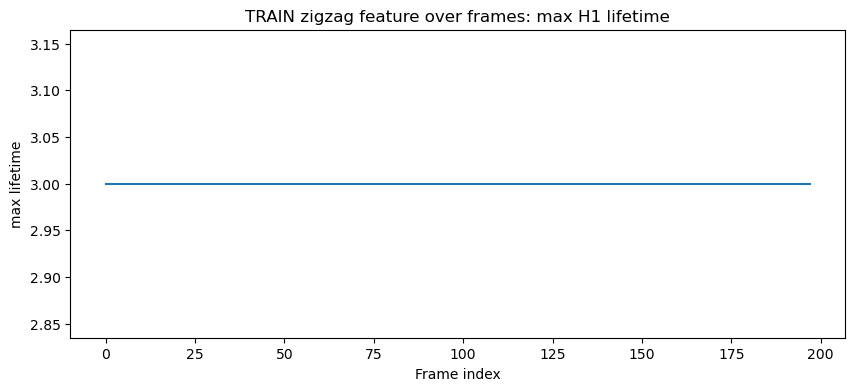

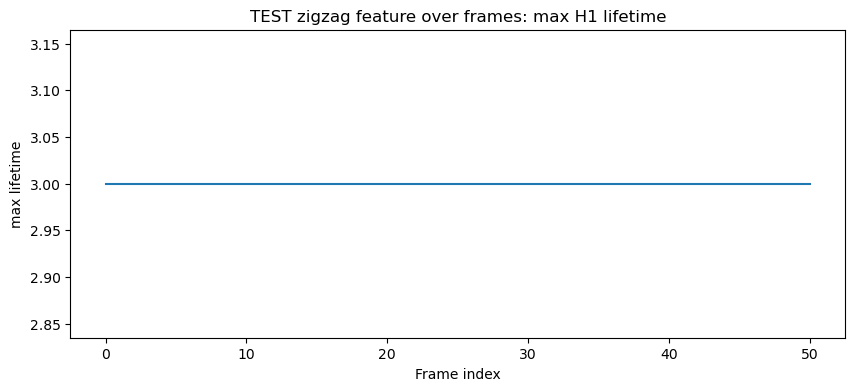

In [23]:
import numpy as np
import dionysus as d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------------------------
# Settings (tune if slow)
# --------------------------
FRAME_SIZE = 200
STRIDE     = 50
MAXDIM     = 1
MAXDIST    = 2.0

def entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    p = x / (x.sum() + 1e-12)
    return float(-(p * np.log(p + 1e-12)).sum())

def zigzag_local_features(points_union, in_left, in_right, maxdim=1, maxdist=2.0):
    """
    True zigzag on 3 stages: Left -> Union <- Right
    using Dionysus zigzag_homology_persistence(filtration, times).

    points_union: (m, D) union points
    in_left:  boolean mask length m (True if vertex in Left frame)
    in_right: boolean mask length m (True if vertex in Right frame)

    Returns: feature vector for stage 1 (Union) based on H1 lifetimes
    """
    # Reduce to 3D for speed/stability
    pts3 = PCA(n_components=3).fit_transform(points_union)

    # Build ONE Rips filtration on union vertex set
    f = d.fill_rips(pts3, maxdim, maxdist)
    f.sort()

    # Assign simplex existence times across stages 0,1,2 (we use [birth, death) indexing)
    # Stage indices: 0=Left, 1=Union, 2=Right
    # We encode times in a 0..3 axis so that:
    # - existence in stage 0 means interval starts at 0
    # - existence through stage 1 means death >= 2
    # - existence through stage 2 means death = 3
    #
    # Rule: simplex exists in Left iff all vertices in_left
    #       simplex exists in Right iff all vertices in_right
    #       simplex always exists in Union (stage 1) because union contains all vertices

    times = []
    for s in f:
        verts = list(s)
        left_ok  = all(in_left[v]  for v in verts)
        right_ok = all(in_right[v] for v in verts)

        if left_ok and right_ok:
            times.append([0.0, 3.0])   # present in all stages
        elif left_ok and not right_ok:
            times.append([0.0, 2.0])   # stages 0 and 1
        elif (not left_ok) and right_ok:
            times.append([1.0, 3.0])   # stages 1 and 2
        else:
            times.append([1.0, 2.0])   # only stage 1

    # True zigzag persistence (supported signature in your build)
    zz, dgms, _ = d.zigzag_homology_persistence(f, times, prime=2, progress=False)

    # dgms[1] is H1 diagram
    if len(dgms) <= 1 or len(dgms[1]) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    H1 = dgms[1]
    pers = []
    for p in H1:
        b = getattr(p, "birth", None)
        dt = getattr(p, "death", None)
        if b is None or dt is None:
            try:
                b, dt = float(p[0]), float(p[1])
            except Exception:
                continue
        if np.isfinite(dt) and np.isfinite(b) and dt > b:
            pers.append(dt - b)

    pers = np.array(pers, dtype=float)
    if len(pers) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    return np.array([
        len(pers),
        pers.max(),
        pers.mean(),
        entropy(pers)
    ], dtype=float)

def zigzag_sequence_features(Z_last, frame_size=200, stride=50, maxdim=1, maxdist=2.0, max_pairs=None):
    """
    Computes local zigzag features for each adjacent frame pair.
    Then builds per-frame features by averaging adjacent pair features.
    Returns per-sample features (aligned to Z_last indices) and per-frame features.
    """
    frames_idx = [np.arange(i, i+frame_size) for i in range(0, len(Z_last) - frame_size + 1, stride)]
    n_frames = len(frames_idx)

    # Optional cap for speed debugging
    pair_count = n_frames - 1
    if max_pairs is not None:
        pair_count = min(pair_count, max_pairs)

    pair_feats = []
    for i in range(pair_count):
        idx_left = frames_idx[i]
        idx_right = frames_idx[i+1]

        # union index set (use sorted unique)
        idx_union = np.unique(np.concatenate([idx_left, idx_right]))
        pts_union = Z_last[idx_union]

        # map global indices -> local vertex ids 0..m-1
        pos = {g: j for j, g in enumerate(idx_union)}
        in_left  = np.zeros(len(idx_union), dtype=bool)
        in_right = np.zeros(len(idx_union), dtype=bool)

        for g in idx_left:
            in_left[pos[g]] = True
        for g in idx_right:
            in_right[pos[g]] = True

        feat = zigzag_local_features(pts_union, in_left, in_right, maxdim=maxdim, maxdist=maxdist)
        pair_feats.append(feat)

        if (i + 1) % 10 == 0:
            print(f"  computed local zigzag {i+1}/{pair_count}")

    pair_feats = np.array(pair_feats, dtype=float)  # (pair_count, 4)

    # Build per-frame features:
    # frame 0 uses pair 0
    # frame i uses average(pair i-1, pair i)
    # last frame uses last pair
    per_frame = []
    for i in range(n_frames):
        if i == 0:
            per_frame.append(pair_feats[0])
        elif i >= pair_count:
            per_frame.append(pair_feats[pair_count-1])
        else:
            per_frame.append(0.5 * (pair_feats[i-1] + pair_feats[i]))
    per_frame = np.array(per_frame, dtype=float)  # (n_frames, 4)

    # Map each sample to its frame index (same as before)
    sample_to_frame = np.minimum(np.arange(len(Z_last)) // stride, n_frames - 1)
    per_sample = per_frame[sample_to_frame]  # (N, 4)

    return per_sample, per_frame

# --------------------------
# Load latent sequences
# --------------------------
latent_train_seq = np.load("latent_train_seq_bi.npy")
latent_test_seq  = np.load("latent_test_seq_bi.npy")
Z_train_last = latent_train_seq[:, -1, :]
Z_test_last  = latent_test_seq[:, -1, :]

print("Z_train_last:", Z_train_last.shape)
print("Z_test_last :", Z_test_last.shape)

print("\n=== TRAIN local zigzag ===")
zigzag_train_per_sample, zigzag_train_per_frame = zigzag_sequence_features(
    Z_train_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\n=== TEST local zigzag ===")
zigzag_test_per_sample, zigzag_test_per_frame = zigzag_sequence_features(
    Z_test_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\nShapes:")
print("zigzag_train_per_sample:", zigzag_train_per_sample.shape)
print("zigzag_test_per_sample :", zigzag_test_per_sample.shape)

np.save("zigzag_train_per_sample_bi.npy", zigzag_train_per_sample)
np.save("zigzag_test_per_sample_bi.npy", zigzag_test_per_sample)
np.save("zigzag_train_per_frame_bi.npy", zigzag_train_per_frame)
np.save("zigzag_test_per_frame_bi.npy", zigzag_test_per_frame)

print("\nSaved zigzag feature files.")

# --------------------------
# Quick visualization
# --------------------------
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 1])  # max lifetime
plt.title("TRAIN zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(zigzag_test_per_frame[:, 1])  # max lifetime
plt.title("TEST zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()


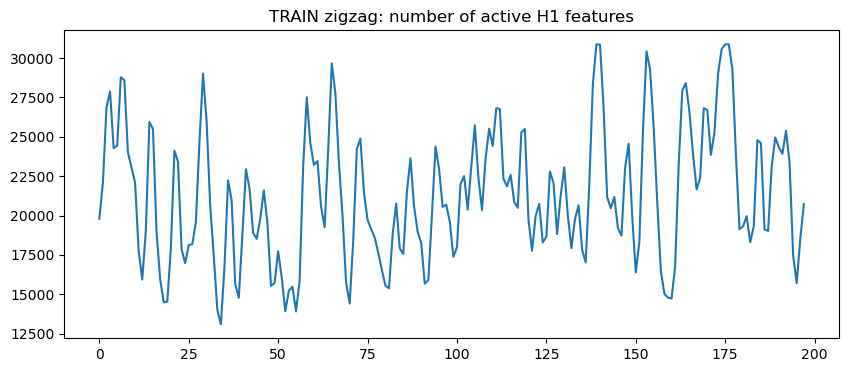

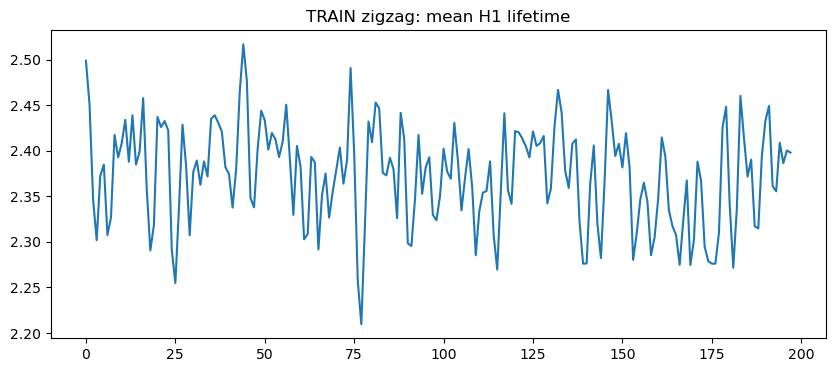

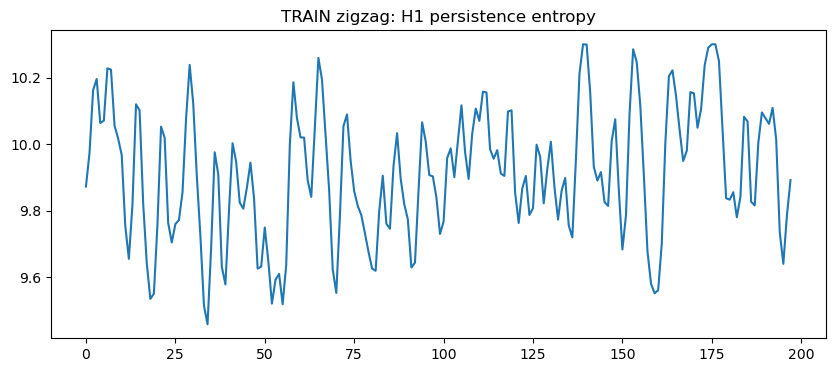

In [24]:
# 1) Number of active H1 features
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 0])
plt.title("TRAIN zigzag: number of active H1 features")
plt.show()

# 2) Mean lifetime
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 2])
plt.title("TRAIN zigzag: mean H1 lifetime")
plt.show()

# 3) Entropy (this one is key)
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 3])
plt.title("TRAIN zigzag: H1 persistence entropy")
plt.show()


In [25]:
import numpy as np

# load
phi_train = np.load("zigzag_train_per_sample_bi.npy")
phi_test  = np.load("zigzag_test_per_sample_bi.npy")

print("X_train:", Xtr.shape)
print("y_train:", ytr.shape)
print("phi_train:", phi_train.shape)

print("X_test:", Xte.shape)
print("y_test:", yte.shape)
print("phi_test:", phi_test.shape)



X_train: (10067, 180, 2)
y_train: (10067,)
phi_train: (10067, 4)
X_test: (2742, 180, 2)
y_test: (2742,)
phi_test: (2742, 4)


In [26]:
# hard alignment checks
assert len(Xtr) == len(phi_train), "Train mismatch: X_train and phi_train lengths differ!"
assert len(Xte)  == len(phi_test),  "Test mismatch: X_test and phi_test lengths differ!"

print("Alignment OK: phi matches X by sample index")
print("phi_train stats (mean, std):")
print(phi_train.mean(axis=0), phi_train.std(axis=0))


Alignment OK: phi matches X by sample index
phi_train stats (mean, std):
[2.12855402e+04 3.00000000e+00 2.37388616e+00 9.91236772e+00] [4.14150748e+03 0.00000000e+00 5.42380558e-02 1.92933303e-01]


In [27]:
import numpy as np

phi_train = np.load("zigzag_train_per_sample_bi.npy").astype(np.float32)
phi_test  = np.load("zigzag_test_per_sample_bi.npy").astype(np.float32)

# 1) detect constant columns using train
std = phi_train.std(axis=0)
keep = std > 1e-8
print("std:", std)
print("keep mask:", keep)

phi_train_k = phi_train[:, keep]
phi_test_k  = phi_test[:, keep]
print("kept dims:", phi_train_k.shape[1])

# 2) normalize using train statistics only
mu = phi_train_k.mean(axis=0, keepdims=True)
sd = phi_train_k.std(axis=0, keepdims=True) + 1e-8

phi_train_n = (phi_train_k - mu) / sd
phi_test_n  = (phi_test_k  - mu) / sd

print("normalized train mean ~0:", phi_train_n.mean(axis=0))
print("normalized train std  ~1:", phi_train_n.std(axis=0))


std: [4.1414644e+03 0.0000000e+00 5.4238141e-02 1.9293228e-01]
keep mask: [ True False  True  True]
kept dims: 3
normalized train mean ~0: [-1.9401261e-07  9.3974859e-07 -4.3652838e-07]
normalized train std  ~1: [1.         0.99999976 0.9999999 ]


In [28]:
#3A) Dataset + DataLoader


import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y, phi=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        self.phi = None if phi is None else torch.tensor(phi, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.phi is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.phi[idx]

batch_size = 128

train_base = DataLoader(SeqDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
test_base  = DataLoader(SeqDataset(Xte, yte), batch_size=batch_size, shuffle=False)

train_aug  = DataLoader(SeqDataset(Xtr, ytr, phi_train_n), batch_size=batch_size, shuffle=True)
test_aug   = DataLoader(SeqDataset(Xte, yte, phi_test_n), batch_size=batch_size, shuffle=False)


In [29]:
#3b - Models


import torch.nn as nn

class BiLSTMBase(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        self.head = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, 2H)
        h_last = out[:, -1, :]         # (B, 2H)
        return self.head(h_last)       # (B, 1)

class BiLSTMTopoAug(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, num_layers=1, topo_dim=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        z = torch.cat([h_last, phi], dim=1)
        return self.head(z)


## Train the topo-augmented BiLSTM (baseline + augmented)

We’ll train two models:

- Baseline BiLSTM: uses only X

- Topo-aug BiLSTM: uses X + phi_norm (3 dims)

Below is a complete, minimal PyTorch setup you can paste. It assumes:

X_train, y_train, X_test, y_test are numpy arrays like your shapes show.

phi_train_n, phi_test_n are the normalized arrays we just created.

In [30]:
# 3c - 3C) Train + Evaluate functions


import torch
import numpy as np

def train_one(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()
    total = 0.0
    n = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            yhat = model(x)
        else:
            x, y, phi = batch
            x, y, phi = x.to(device), y.to(device), phi.to(device)
            yhat = model(x, phi)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
        n += len(x)
    return total / n

@torch.no_grad()
def eval_rmse_mae(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())
    preds = np.vstack(preds).ravel()
    trues = np.vstack(trues).ravel()
    rmse = np.sqrt(np.mean((preds - trues)**2))
    mae  = np.mean(np.abs(preds - trues))
    return rmse, mae


In [31]:
#3D) Run baseline vs augmented

import os, torch

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

best_rmse_base = float("inf")
best_rmse_aug  = float("inf")
patience = 10
no_improve_base = 0
no_improve_aug  = 0


In [32]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# reproducibility (important for comparison)
torch.manual_seed(0)
np.random.seed(0)

# ----- instantiate models -----
base = BiLSTMBase(
    input_dim=2,
    hidden_dim=128
).to(device)

aug = BiLSTMTopoAug(
    input_dim=2,
    hidden_dim=128,
    topo_dim=phi_train_n.shape[1]
).to(device)

# ----- optimizers -----
opt_base = torch.optim.Adam(base.parameters(), lr=1e-3)
opt_aug  = torch.optim.Adam(aug.parameters(),  lr=1e-3)

print("Models and optimizers initialized")


Using device: cpu
Models and optimizers initialized


In [33]:
max_epochs = 200

for ep in range(1, max_epochs + 1):
    lb = train_one(base, train_base, opt_base, device)
    la = train_one(aug,  train_aug,  opt_aug,  device)

    rmse_b, mae_b = eval_rmse_mae(base, test_base, device)
    rmse_a, mae_a = eval_rmse_mae(aug,  test_aug,  device)

    print(f"Epoch {ep:02d} | base loss {lb:.4f} rmse {rmse_b:.4f} mae {mae_b:.4f} "
          f"| aug loss {la:.4f} rmse {rmse_a:.4f} mae {mae_a:.4f}")

    # ---- baseline checkpoint ----
    if rmse_b < best_rmse_base - 1e-6:
        best_rmse_base = rmse_b
        no_improve_base = 0
        torch.save({
            "model_state": base.state_dict(),
            "optimizer_state": opt_base.state_dict(),
            "rmse": rmse_b,
            "config": {"model":"BiLSTMBase","input_dim":2,"hidden_dim":128,"lookback": Xtr.shape[1]}
        }, f"{SAVE_DIR}/bilstm_base_best_bi.pt")
        print(" Saved best baseline")
    else:
        no_improve_base += 1

    # ---- topo-aug checkpoint ----
    if rmse_a < best_rmse_aug - 1e-6:
        best_rmse_aug = rmse_a
        no_improve_aug = 0
        torch.save({
            "model_state": aug.state_dict(),
            "optimizer_state": opt_aug.state_dict(),
            "rmse": rmse_a,
            "config": {"model":"BiLSTMTopoAug","input_dim":2,"hidden_dim":128,"topo_dim":phi_train_n.shape[1],"lookback": Xtr.shape[1]},
            "zigzag_norm": {"mu": mu, "sd": sd, "keep_mask": keep}
        }, f"{SAVE_DIR}/bilstm_topo_aug_best_bi.pt")
        print("Saved best topo-aug")
    else:
        no_improve_aug += 1

    # ---- early stopping condition (stop when BOTH stop improving) ----
    if no_improve_base >= patience and no_improve_aug >= patience:
        print(f"⏹ Early stopping at epoch {ep} (no improvement for {patience} epochs).")
        break

print("Best RMSE baseline:", best_rmse_base)
print("Best RMSE topo-aug:", best_rmse_aug)


Epoch 01 | base loss 0.1958 rmse 0.1060 mae 0.0791 | aug loss 0.1522 rmse 0.0915 mae 0.0750
 Saved best baseline
Saved best topo-aug
Epoch 02 | base loss 0.0050 rmse 0.0713 mae 0.0494 | aug loss 0.0034 rmse 0.0482 mae 0.0358
 Saved best baseline
Saved best topo-aug
Epoch 03 | base loss 0.0021 rmse 0.0540 mae 0.0371 | aug loss 0.0010 rmse 0.0357 mae 0.0258
 Saved best baseline
Saved best topo-aug
Epoch 04 | base loss 0.0010 rmse 0.0418 mae 0.0298 | aug loss 0.0005 rmse 0.0269 mae 0.0190
 Saved best baseline
Saved best topo-aug
Epoch 05 | base loss 0.0006 rmse 0.0348 mae 0.0228 | aug loss 0.0003 rmse 0.0240 mae 0.0169
 Saved best baseline
Saved best topo-aug
Epoch 06 | base loss 0.0005 rmse 0.0313 mae 0.0209 | aug loss 0.0002 rmse 0.0200 mae 0.0140
 Saved best baseline
Saved best topo-aug
Epoch 07 | base loss 0.0005 rmse 0.0291 mae 0.0197 | aug loss 0.0002 rmse 0.0187 mae 0.0133
 Saved best baseline
Saved best topo-aug
Epoch 08 | base loss 0.0004 rmse 0.0273 mae 0.0179 | aug loss 0.0001 

# Vizualization and Analysis

In [34]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_b = torch.load("saved_models/bilstm_base_best_bi.pt", map_location=device, weights_only=False)
ckpt_a = torch.load("saved_models/bilstm_topo_aug_best_bi.pt", map_location=device, weights_only=False)

print("Loaded checkpoints with weights_only=False")
print("baseline keys:", ckpt_b.keys())
print("aug keys:", ckpt_a.keys())


Loaded checkpoints with weights_only=False
baseline keys: dict_keys(['model_state', 'optimizer_state', 'rmse', 'config'])
aug keys: dict_keys(['model_state', 'optimizer_state', 'rmse', 'config', 'zigzag_norm'])


In [35]:
import torch, numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load baseline checkpoint ----
ckpt_b = torch.load(
    "saved_models/bilstm_base_best_bi.pt",
    map_location=device,
    weights_only=False  
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"]
).to(device)
base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()

# ---- load topo-aug checkpoint ----
ckpt_a = torch.load(
    "saved_models/bilstm_topo_aug_best_bi.pt",
    map_location=device,
    weights_only=False   # IMPORTANT
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    topo_dim=ckpt_a["config"]["topo_dim"]
).to(device)
aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()

# ---- restore zigzag normalization from checkpoint ----
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

print("Loaded best models.")
print("Baseline best RMSE:", ckpt_b["rmse"])
print("Topo-aug best RMSE:", ckpt_a["rmse"])
print("Topo keep mask:", keep)


Loaded best models.
Baseline best RMSE: 0.0030824703
Topo-aug best RMSE: 0.0037229124
Topo keep mask: [ True False  True  True]


In [64]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_rmse_mae_base(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            ys.append(yb.cpu().numpy())
            preds.append(out.cpu().numpy())
    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

def eval_rmse_mae_aug(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:  # (X, y, phi)
            xb  = batch[0].to(device)
            yb  = batch[1].to(device)
            phi = batch[2].to(device)
            out = model(xb, phi)   # IMPORTANT
            ys.append(yb.cpu().numpy())
            preds.append(out.cpu().numpy())
    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

In [65]:
rmse_b, mae_b = eval_rmse_mae_base(base, test_base, device)
rmse_a, mae_a = eval_rmse_mae_aug(aug,  test_aug,  device)

In [66]:
print(eval_rmse_mae_base(base_best, test_base, device))
print(eval_rmse_mae_aug(aug_best,  test_aug,  device))

(np.float64(0.0030824702798491893), 0.0020029430743306875)
(np.float64(0.0037229124567525643), 0.002667136723175645)


In [67]:
import numpy as np
print("Baseline |err| p95:", np.percentile(np.abs(y_true_b - y_pred_b), 95))
print("Topo-aug |err| p95:", np.percentile(np.abs(y_true_a - y_pred_a), 95))

Baseline |err| p95: 0.0063215955
Topo-aug |err| p95: 0.0076265614


In [68]:
import numpy as np
print("Targets match?", np.allclose(y_true_b, y_true_a))

Targets match? True


In [59]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_full_base(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

In [60]:
def eval_full_aug(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:
            xb  = batch[0].to(device)   # [B,180,2]
            yb  = batch[1].to(device)   # [B,1]
            phi = batch[2].to(device)   # [B,3]

            out = model(xb, phi)        # <-- IMPORTANT

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

In [61]:
rmse_b, mae_b, y_true_b, y_pred_b = eval_full_base(base_best, test_base, device)
rmse_a, mae_a, y_true_a, y_pred_a = eval_full_aug(aug_best,  test_aug,  device)

print(rmse_b, mae_b, y_true_b.shape, y_pred_b.shape)
print(rmse_a, mae_a, y_true_a.shape, y_pred_a.shape)

0.0030824702798491893 0.0020029430743306875 (2742,) (2742,)
0.0037229124567525643 0.002667136723175645 (2742,) (2742,)


In [62]:
from sklearn.metrics import mean_absolute_error

mae_b = mean_absolute_error(y_true, y_pred_b)
mae_a = mean_absolute_error(y_true, y_pred_a)

print("Baseline MAE:", mae_b)
print("Topo-aug MAE:", mae_a)

Baseline MAE: 0.0020029430743306875
Topo-aug MAE: 0.002667136723175645


In [63]:
from sklearn.metrics import r2_score
print("Baseline R²:", r2_score(y_true_b, y_pred_b))
print("Topo-aug R²:", r2_score(y_true_a, y_pred_a))

Baseline R²: 0.9999908208847046
Topo-aug R²: 0.9999866485595703


In [58]:
batch = next(iter(test_aug))
print(type(batch), len(batch))
for i, item in enumerate(batch):
    try:
        print(i, item.shape, item.dtype)
    except:
        print(i, type(item))



<class 'list'> 3
0 torch.Size([128, 180, 2]) torch.float32
1 torch.Size([128, 1]) torch.float32
2 torch.Size([128, 3]) torch.float32


In [36]:
import numpy as np

phi_test_raw = np.load("zigzag_test_per_sample_bi.npy").astype(np.float32)

# keep only non-constant columns (same mask as training)
phi_test_k = phi_test_raw[:, keep]

# normalize using train stats saved in checkpoint
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("phi_test_n shape:", phi_test_n.shape)
print("phi_test_n mean/std (rough):", phi_test_n.mean(axis=0), phi_test_n.std(axis=0))


phi_test_n shape: (2742, 3)
phi_test_n mean/std (rough): [-0.16232277  0.05920098 -0.13404633] [0.7701435 1.111598  0.7954693]


In [37]:
import torch
import numpy as np

@torch.no_grad()
def extract_h_last_from_lstm(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    outs = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        out, _ = model.lstm(xb)       # (B, T, 2H)
        h_last = out[:, -1, :]        # (B, 2H)
        outs.append(h_last.cpu().numpy())
    return np.vstack(outs)

@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yhat = model(xb).cpu().numpy()
        preds.append(yhat)
    return np.vstack(preds).ravel()

@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()
        preds.append(yhat)
    return np.vstack(preds).ravel()


In [38]:
from sklearn.decomposition import PCA
import numpy as np

# 1) Extract last hidden state (test set is enough to start)
Zb_te = extract_h_last_from_lstm(base_best, Xte, device)
Za_te = extract_h_last_from_lstm(aug_best,  Xte, device)

print("Zb_te:", Zb_te.shape, "Za_te:", Za_te.shape)

# 2) Fit PCA on *combined* test latents for a fair comparison
Z_all = np.vstack([Zb_te, Za_te])
pca = PCA(n_components=3, random_state=0).fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

# 3) Predictions + absolute errors
pred_b = predict_base(base_best, Xte, device)
pred_a = predict_aug(aug_best, Xte, phi_test_n, device)

err_b = np.abs(pred_b - yte)
err_a = np.abs(pred_a - yte)

print("Pred shapes:", pred_b.shape, pred_a.shape)
print("Error mean baseline vs aug:", err_b.mean(), err_a.mean())


Zb_te: (2742, 256) Za_te: (2742, 256)
Pred shapes: (2742,) (2742,)
Error mean baseline vs aug: 0.0020029424 0.0026671384


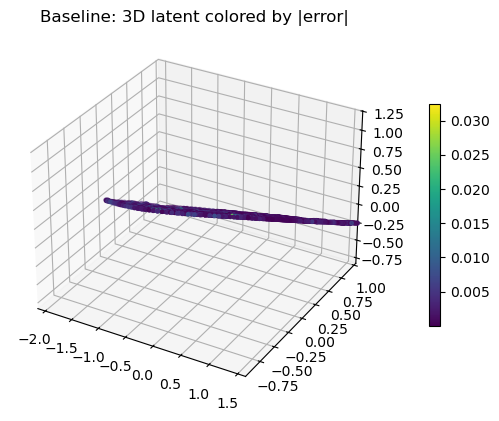

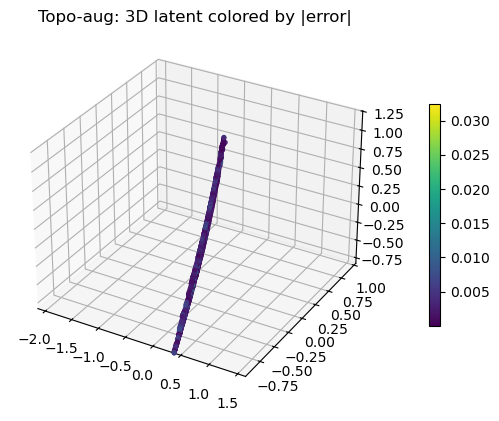

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_same_axes(Z3, values, title, lims, vmin=None, vmax=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)

    ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
    plt.show()

# shared limits across both
lims = (
    (min(Zb_te3[:,0].min(), Za_te3[:,0].min()), max(Zb_te3[:,0].max(), Za_te3[:,0].max())),
    (min(Zb_te3[:,1].min(), Za_te3[:,1].min()), max(Zb_te3[:,1].max(), Za_te3[:,1].max())),
    (min(Zb_te3[:,2].min(), Za_te3[:,2].min()), max(Zb_te3[:,2].max(), Za_te3[:,2].max())),
)

# shared color scale too
vmin = min(err_b.min(), err_a.min())
vmax = max(err_b.max(), err_a.max())

plot_3d_same_axes(Zb_te3, err_b, "Baseline: 3D latent colored by |error|", lims, vmin, vmax)
plot_3d_same_axes(Za_te3, err_a, "Topo-aug: 3D latent colored by |error|", lims, vmin, vmax)

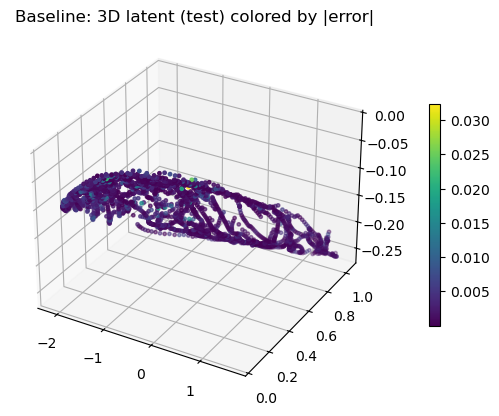

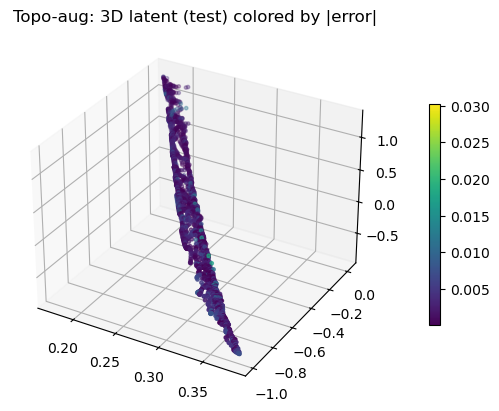

In [39]:
import matplotlib.pyplot as plt

def plot_3d(Z3, values, title):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)
    plt.show()

plot_3d(Zb_te3, err_b, "Baseline: 3D latent (test) colored by |error|")
plot_3d(Za_te3, err_a, "Topo-aug: 3D latent (test) colored by |error|")


In [70]:
# import matplotlib.pyplot as plt
# import numpy as np

# y_true = y_true_b  # since they match

# plt.figure(figsize=(14,4))
# plt.plot(y_true, label="True")
# plt.plot(y_pred_b, label="Baseline pred")
# plt.plot(y_pred_a, label="Topo-aug pred")
# plt.title("Test set: True vs Predictions")
# plt.xlabel("Test sample index (time order)")
# plt.ylabel("Target (scaled units unless inverse-transformed)")
# plt.legend()
# plt.tight_layout()
# plt.show()
import numpy as np

print("max |True - Baseline| :", np.max(np.abs(y_true - y_pred_b)))
print("max |True - Topo|     :", np.max(np.abs(y_true - y_pred_a)))
print("max |Baseline - Topo| :", np.max(np.abs(y_pred_b - y_pred_a)))

max |True - Baseline| : 0.03240481
max |True - Topo|     : 0.030278146
max |Baseline - Topo| : 0.014253378


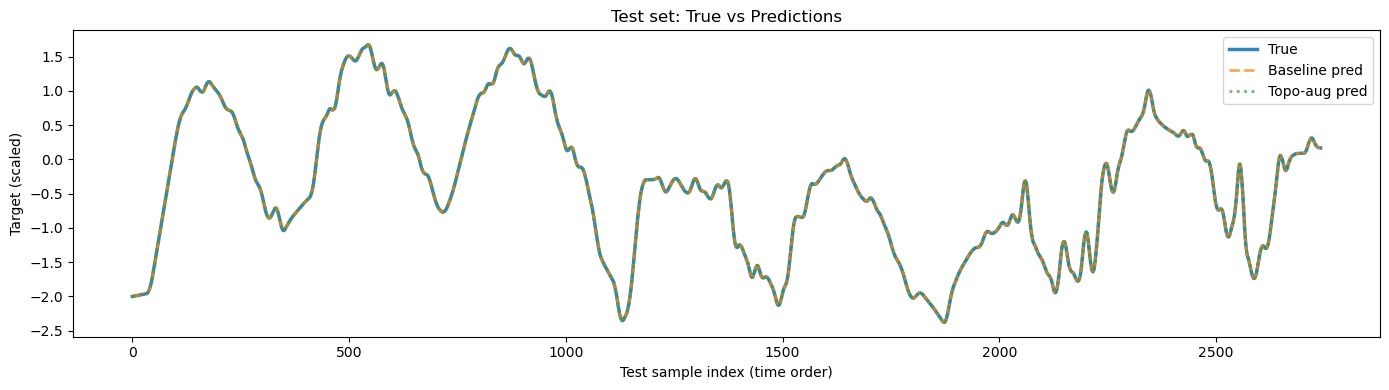

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(y_true,   label="True",          linewidth=2.5, alpha=0.9, linestyle='-')
plt.plot(y_pred_b, label="Baseline pred", linewidth=2.0, alpha=0.7, linestyle='--')
plt.plot(y_pred_a, label="Topo-aug pred", linewidth=2.0, alpha=0.7, linestyle=':')
plt.title("Test set: True vs Predictions")
plt.xlabel("Test sample index (time order)")
plt.ylabel("Target (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
from sklearn.decomposition import PCA
import numpy as np

# Zb_te: (N, D) baseline latents
# Za_te: (N, D) topo-aug latents

Z_all = np.vstack([Zb_te, Za_te])

pca = PCA(n_components=3, random_state=0)
pca.fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

In [46]:
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

print("Baseline step variance:", d_b.std())
print("Topo-aug step variance:", d_a.std())

Baseline step variance: 0.029594135
Topo-aug step variance: 0.021541601


In [47]:
print("Baseline mean step:", d_b.mean(), "std:", d_b.std())
print("Topo-aug mean step:", d_a.mean(), "std:", d_a.std())

Baseline mean step: 0.034441285 std: 0.029594135
Topo-aug mean step: 0.021939775 std: 0.021541601


In [48]:
import numpy as np

def perm_test_var_ratio(a, b, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.var(a) / np.var(b)
    pooled = np.concatenate([a, b])
    n = len(a)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        a_p = pooled[:n]
        b_p = pooled[n:]
        stat = np.var(a_p) / np.var(b_p)
        if stat >= obs:
            count += 1
    return obs, (count + 1) / (n_perm + 1)

obs, p = perm_test_var_ratio(d_b, d_a)
print("Var ratio (baseline/topo):", obs, "p-value:", p)

Var ratio (baseline/topo): 1.8873626 p-value: 0.0001999600079984003


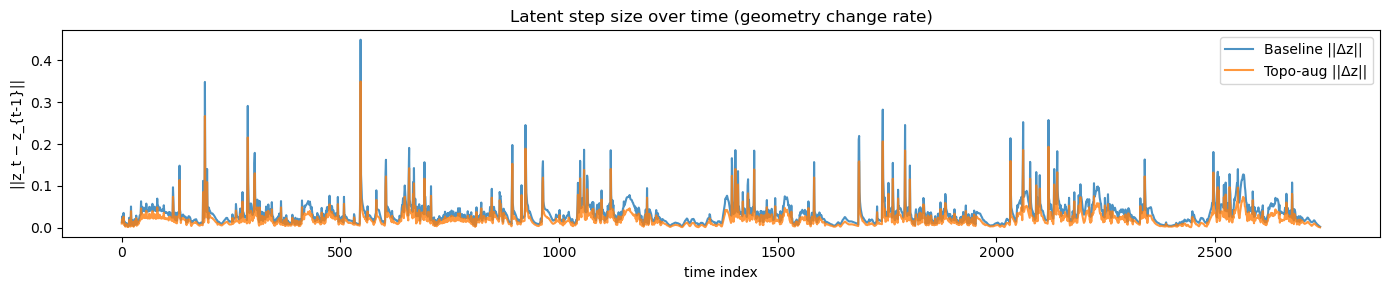

In [75]:
import numpy as np, matplotlib.pyplot as plt

d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

plt.figure(figsize=(14,3))
plt.plot(d_b, label="Baseline ||Δz||", alpha=0.8)
plt.plot(d_a, label="Topo-aug ||Δz||", alpha=0.8)
plt.title("Latent step size over time (geometry change rate)")
plt.xlabel("time index")
plt.ylabel("||z_t − z_{t-1}||")
plt.legend()
plt.tight_layout()
plt.show()

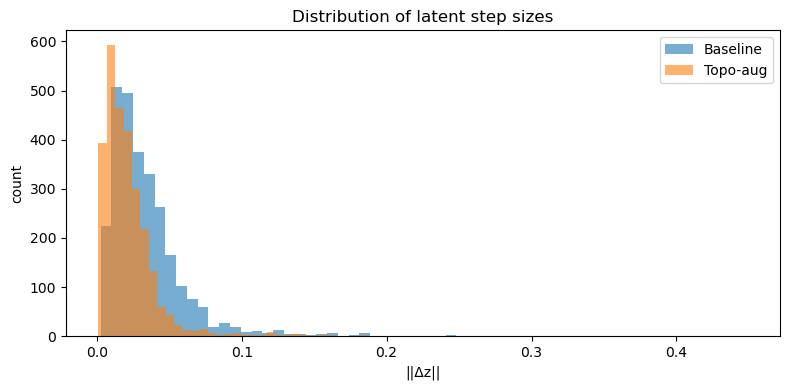

In [76]:
plt.figure(figsize=(8,4))
plt.hist(d_b, bins=60, alpha=0.6, label="Baseline")
plt.hist(d_a, bins=60, alpha=0.6, label="Topo-aug")
plt.title("Distribution of latent step sizes")
plt.xlabel("||Δz||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

## Local neighborhood scale (kNN radius) over time

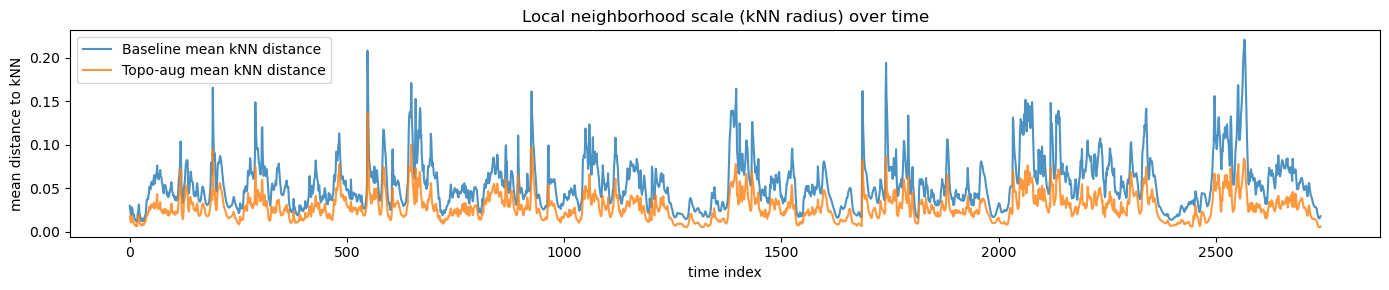

kNN radius std baseline: 0.028970807111487418
kNN radius std topo:     0.014945498617442925


In [78]:
from sklearn.neighbors import NearestNeighbors
import numpy as np, matplotlib.pyplot as plt

def knn_radius(Z, k=10):
    nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
    dists, _ = nn.kneighbors(Z)        # first neighbor is itself
    return dists[:, 1:].mean(axis=1)   # mean distance to k nearest neighbors

r_b = knn_radius(Zb_te, k=10)
r_a = knn_radius(Za_te, k=10)

plt.figure(figsize=(14,3))
plt.plot(r_b, label="Baseline mean kNN distance", alpha=0.8)
plt.plot(r_a, label="Topo-aug mean kNN distance", alpha=0.8)
plt.title("Local neighborhood scale (kNN radius) over time")
plt.xlabel("time index")
plt.ylabel("mean distance to kNN")
plt.legend()
plt.tight_layout()
plt.show()

print("kNN radius std baseline:", r_b.std())
print("kNN radius std topo:    ", r_a.std())

## F-statistic

In [83]:
import numpy as np
from scipy.stats import f

# sample sizes
n_b = len(r_b)
n_a = len(r_a)

# variances
var_b = np.var(r_b, ddof=1)
var_a = np.var(r_a, ddof=1)

# F statistic
F = var_b / var_a

# degrees of freedom
df1 = n_b - 1
df2 = n_a - 1

# one-sided p-value
p_value = 1 - f.cdf(F, df1, df2)

print("Variance baseline:", var_b)
print("Variance topo:", var_a)
print("F statistic:", F)
print("p-value:", p_value)

Variance baseline: 0.0008396138696033378
Variance topo: 0.00022344942032454434
F statistic: 3.757511961247689
p-value: 1.1102230246251565e-16


In [84]:
print("Variance ratio (baseline/topo):", var_b / var_a)

Variance ratio (baseline/topo): 3.757511961247689


## Plots

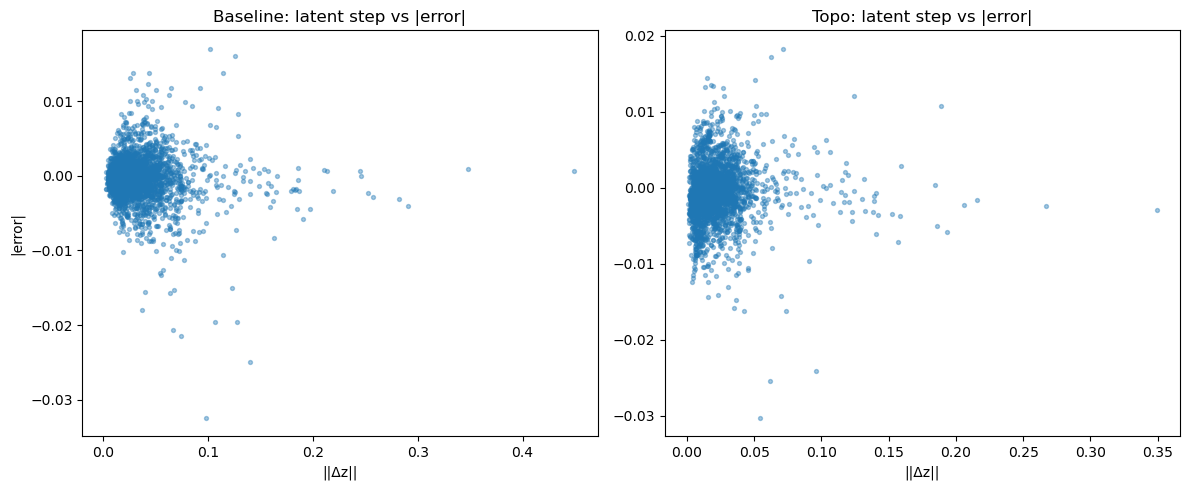

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(d_b, err_b_aligned, s=8, alpha=0.4)
plt.title("Baseline: latent step vs |error|")
plt.xlabel("||Δz||")
plt.ylabel("|error|")

plt.subplot(1,2,2)
plt.scatter(d_a, err_a_aligned, s=8, alpha=0.4)
plt.title("Topo: latent step vs |error|")
plt.xlabel("||Δz||")

plt.tight_layout()
plt.show()

In [88]:
threshold_b = np.percentile(err_b_aligned, 95)
threshold_a = np.percentile(err_a_aligned, 95)

spike_idx_b = err_b_aligned >= threshold_b
spike_idx_a = err_a_aligned >= threshold_a

print("Baseline mean step size during spikes:",
      d_b[spike_idx_b].mean())

print("Baseline mean step size normal:",
      d_b[~spike_idx_b].mean())

print()
print("Topo mean step size during spikes:",
      d_a[spike_idx_a].mean())

print("Topo mean step size normal:",
      d_a[~spike_idx_a].mean())

Baseline mean step size during spikes: 0.043820884
Baseline mean step size normal: 0.03394402

Topo mean step size during spikes: 0.026353728
Topo mean step size normal: 0.021705769


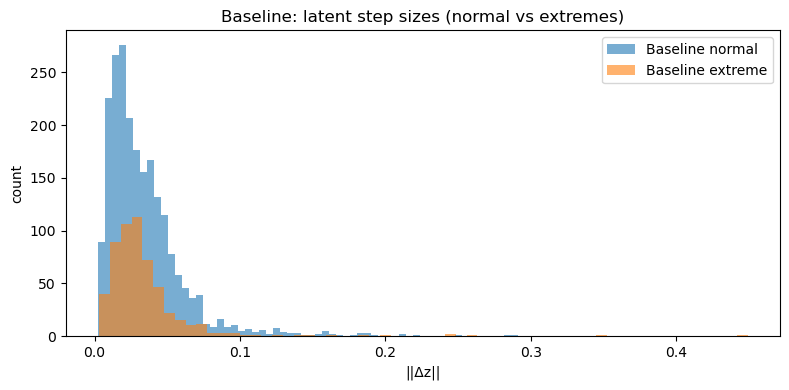

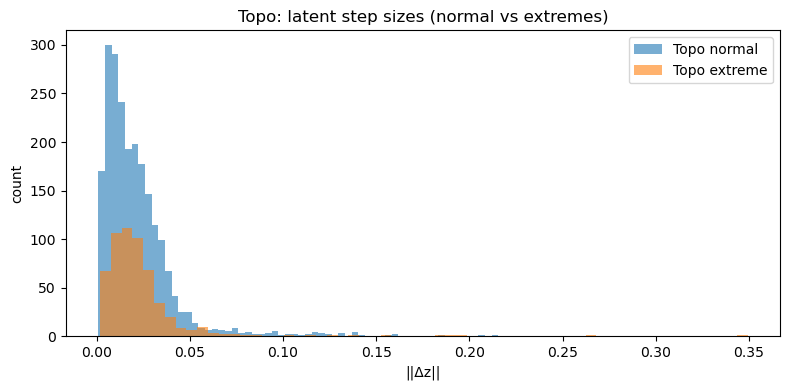

Baseline mean ||Δz|| normal: 0.034420308 extreme: 0.03452504
Topo mean ||Δz|| normal: 0.021507781 extreme: 0.023664603
Ratio extreme/normal baseline: 1.0030428
Ratio extreme/normal topo: 1.100281


In [89]:
import numpy as np
import matplotlib.pyplot as plt

y_true = y_true_b  # assuming identical targets

# latent step sizes aligned to time t (length N-1)
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

# choose extremes by storage (top/bottom 10%)
q_low, q_high = np.percentile(y_true, [10, 90])
extreme_mask = (y_true <= q_low) | (y_true >= q_high)
extreme_mask = extreme_mask[1:]  # align with d_* (starts at t=1)

plt.figure(figsize=(8,4))
plt.hist(d_b[~extreme_mask], bins=60, alpha=0.6, label="Baseline normal")
plt.hist(d_b[extreme_mask],  bins=60, alpha=0.6, label="Baseline extreme")
plt.title("Baseline: latent step sizes (normal vs extremes)")
plt.xlabel("||Δz||"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.hist(d_a[~extreme_mask], bins=60, alpha=0.6, label="Topo normal")
plt.hist(d_a[extreme_mask],  bins=60, alpha=0.6, label="Topo extreme")
plt.title("Topo: latent step sizes (normal vs extremes)")
plt.xlabel("||Δz||"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

print("Baseline mean ||Δz|| normal:", d_b[~extreme_mask].mean(), "extreme:", d_b[extreme_mask].mean())
print("Topo mean ||Δz|| normal:",     d_a[~extreme_mask].mean(), "extreme:", d_a[extreme_mask].mean())
print("Ratio extreme/normal baseline:", d_b[extreme_mask].mean()/d_b[~extreme_mask].mean())
print("Ratio extreme/normal topo:",     d_a[extreme_mask].mean()/d_a[~extreme_mask].mean())